# Lecture 14.2 Детекция объектов

**Тема:** детекция объектов от постановки задачи до Faster R-CNN  
**Цель:** понять, что именно предсказывает детектор, как он оценивается, как устроен Faster R-CNN и как запускать реальный пример в PyTorch



## План

1. Что предсказывает детекция и чем она сложнее классификации  
2. Форматы bounding boxes, IoU, confidence scores и NMS  
3. One-stage и two-stage детекторы  
4. Архитектура Faster R-CNN подробнее  
5. Реальный датасет Penn-Fudan Pedestrian  
6. Практический fine-tuning и визуализация в PyTorch  
7. Оценка через AP и mAP  
8. Области применения, типичные ошибки и упражнения


## 1. Что такое детекция объектов?

Детекция объектов требует от модели одновременно решить три подзадачи:

1. понять, есть ли объект  
2. определить его класс  
3. локализовать его на изображении

Это уже сложнее классификации, потому что выход становится структурированным. Модель возвращает не одну метку, а **набор** предсказаний, где каждое предсказание содержит:

- bounding box  
- класс  
- confidence score

То есть модель должна рассуждать не только о содержании изображения, но и о геометрии, а также о множественности объектов: их может быть ноль, один или много.


![Detection pipeline](images/detection_pipeline.svg)

Схема выше отражает общую логику: детектор превращает одно изображение в набор candidate boxes, затем оценивает и фильтрует их. Фильтрация важна, потому что современные детекторы обычно предсказывают несколько перекрывающихся гипотез для одного и того же объекта.


## 2. Bounding boxes и форматы координат

Прямоугольник кажется простой вещью, пока вы не начнете переносить данные между библиотеками и датасетами. Тогда формат координат быстро становится одним из главных источников ошибок.

Три наиболее частых формата:

- `xyxy`: левый, верхний, правый, нижний край  
- `xywh`: левый верхний угол, ширина, высота  
- `cxcywh`: центр по x, центр по y, ширина, высота

Математически они эквивалентны, но неверная интерпретация дает систематические сбои:

- боксы смещаются  
- размеры становятся неправильными  
- метрики рушатся  
- визуализация выглядит «почти правильно», но не совсем

Поэтому нужно всегда сначала проверять формат координат.


## 3. IoU, confidence и NMS

### IoU

Intersection over Union показывает, насколько сильно перекрываются два бокса:

$$
IoU = \frac{area(Intersection)}{area(Union)}
$$

На практике IoU используется в нескольких местах:

- при сопоставлении предсказаний и ground truth  
- при решении, считать ли detection true positive  
- при подавлении дубликатов

### Confidence score

Confidence score показывает, насколько уверена модель в предсказании. В реальности финальный score часто включает в себя сразу несколько факторов:

- объектность  
- вероятность класса  
- косвенно качество локализации

### NMS

Non-Maximum Suppression убирает дубликаты. Если несколько боксов сильно перекрываются, мы оставляем самый сильный, а остальные подавляем.

Это важная идея: сырые предсказания детектора почти всегда нуждаются в постобработке, чтобы стать удобными для пользователя.


## 4. Почему детекцию труднее оценивать

В классификации часто хватает accuracy. В детекции этого недостаточно, потому что нас интересует сразу несколько вещей:

- нашла ли модель объект  
- правильно ли определила класс  
- достаточно ли хорошо локализовала объект  
- ставит ли хорошие предсказания выше плохих

Именно поэтому стандартом стали AP и mAP. Они учитывают поведение precision-recall кривой, а не одну произвольно выбранную точку отсечения.




## AP и mAP

`AP` и `mAP` — это основные метрики качества в задаче **детекции объектов**.

Они нужны потому, что в детекции мало просто “угадать класс”. Модель должна одновременно:

- найти объект
- правильно определить его класс
- достаточно точно поставить bounding box

## Что такое AP

`AP` = `Average Precision`.

Это метрика качества **для одного класса**.

Например, можно отдельно посчитать `AP` для класса `person`, отдельно для `car`, отдельно для `dog`.

### Основная идея

Детектор выдает много предсказаний с разными значениями уверенности (`confidence score`).

Если мы будем менять порог уверенности, то будет меняться баланс между:

- `precision` — насколько много найденных объектов действительно правильные
- `recall` — насколько много реальных объектов модель вообще смогла найти

Из этих значений строится **precision-recall curve**.

Тогда `AP` — это площадь под этой кривой:

$$
AP = \int_0^1 Precision(Recall)\, dRecall
$$

Интуитивно:

- высокий `AP` означает, что модель хорошо ранжирует предсказания
- правильные detections получают более высокую уверенность, чем неправильные
- при изменении порога модель сохраняет хороший баланс между precision и recall

## Что такое precision и recall

В детекции сначала нужно определить, какое предсказание считается **правильным**.

Обычно предсказание считается `true positive`, если:

- класс определен верно
- `IoU` с истинным bounding box выше заданного порога, например `0.5`

Тогда:

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

Где:

- `TP` — правильно найденные объекты
- `FP` — ложные срабатывания
- `FN` — пропущенные объекты

## Почему AP лучше, чем одна accuracy

Обычная `accuracy` плохо подходит для детекции, потому что здесь:

- на одном изображении может быть много объектов
- модель может выдать много предсказаний
- важен порядок предсказаний по confidence
- важна точность локализации через `IoU`

`AP` гораздо лучше отражает реальное качество детектора.

## Что такое mAP

`mAP` = `mean Average Precision`.

Это **среднее значение AP по нескольким классам**.

Если у нас `K` классов, то:

$$
mAP = \frac{1}{K}\sum_{k=1}^{K} AP_k
$$

То есть:

- сначала считаем `AP` для каждого класса отдельно
- потом усредняем результаты

Пример:

- `AP(person)=0.82`
- `AP(car)=0.76`
- `AP(dog)=0.71`

Тогда:

$$
mAP = \frac{0.82 + 0.76 + 0.71}{3} = 0.763
$$

## Важное уточнение про IoU threshold

Когда пишут `mAP@0.5`, это означает:

- предсказание считается правильным, если `IoU >= 0.5`

Когда пишут `mAP@0.5:0.95`, это означает:

- метрика усредняется по нескольким порогам `IoU`
- обычно от `0.50` до `0.95` с шагом `0.05`

Это более строгая метрика.

### На практике

- `mAP@0.5` обычно выше и “мягче”
- `mAP@0.5:0.95` строже и лучше показывает реальную точность локализации

## Как интерпретировать эти метрики

- высокий `AP` для класса `person` означает, что модель хорошо находит людей
- высокий `mAP` означает, что модель в среднем хорошо работает по всем классам
- если `mAP@0.5` высокий, а `mAP@0.5:0.95` заметно ниже, то модель находит объекты, но ставит bounding boxes не очень точно

## Короткая интуиция

- `AP` — качество детекции **для одного класса**
- `mAP` — среднее качество детекции **по всем классам**

Если совсем коротко:

> `AP` показывает, насколько хорошо детектор работает для одного класса,  
> а `mAP` показывает, насколько хорошо он работает в среднем по всем классам.



## 5. One-stage и two-stage детекторы

### Two-stage

Примеры: Faster R-CNN, Mask R-CNN

Идея:

1. сначала предложить regions of interest  
2. потом классифицировать и уточнить их

Такие модели часто очень точны и логичны с архитектурной точки зрения, но обычно медленнее.

### One-stage

Примеры: SSD, RetinaNet, YOLO

Они сразу предсказывают боксы и классы за один проход. Это делает их быстрее и удобнее для real-time сценариев.

В этом ноутбуке мы разбираем **Faster R-CNN**, потому что это особенно удачная архитектура для обучения.


In [2]:
from __future__ import annotations

import math
import random
from pathlib import Path

import numpy as np

MPL_AVAILABLE = True
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
except Exception as exc:
    MPL_AVAILABLE = False
    print(f"matplotlib is not available: {exc}")

PIL_AVAILABLE = True
try:
    from PIL import Image
except Exception as exc:
    PIL_AVAILABLE = False
    print(f"Pillow is not available: {exc}")

TORCH_AVAILABLE = True
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
except Exception as exc:
    TORCH_AVAILABLE = False
    print(f"PyTorch is not available: {exc}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

print(f"matplotlib available: {MPL_AVAILABLE}")
print(f"Pillow available: {PIL_AVAILABLE}")
print(f"PyTorch available: {TORCH_AVAILABLE}")


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


matplotlib available: True
Pillow available: True
PyTorch available: True


IoU = 0.32


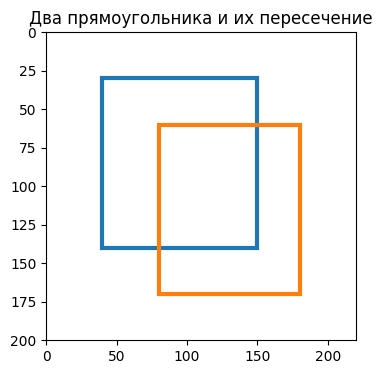

In [3]:
def box_iou_xyxy(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0, xa2 - xa1) * max(0, ya2 - ya1)
    area_b = max(0, xb2 - xb1) * max(0, yb2 - yb1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


box_a = (40, 30, 150, 140)
box_b = (80, 60, 180, 170)

print("IoU =", round(box_iou_xyxy(box_a, box_b), 3))

if MPL_AVAILABLE:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(0, 220)
    ax.set_ylim(200, 0)
    ax.add_patch(patches.Rectangle((40, 30), 110, 110, fill=False, linewidth=3, edgecolor="tab:blue"))
    ax.add_patch(patches.Rectangle((80, 60), 100, 110, fill=False, linewidth=3, edgecolor="tab:orange"))
    ax.set_title("Два прямоугольника и их пересечение")
    plt.show()


![Faster R-CNN](images/faster_rcnn_architecture.svg)



In [6]:
!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -P data
!cd data && unzip PennFudanPed.zip

Archive:  PennFudanPed.zip
   creating: PennFudanPed/
  inflating: PennFudanPed/added-object-list.txt  
   creating: PennFudanPed/Annotation/
  inflating: PennFudanPed/Annotation/FudanPed00001.txt  
  inflating: PennFudanPed/Annotation/FudanPed00002.txt  
  inflating: PennFudanPed/Annotation/FudanPed00003.txt  
  inflating: PennFudanPed/Annotation/FudanPed00004.txt  
  inflating: PennFudanPed/Annotation/FudanPed00005.txt  
  inflating: PennFudanPed/Annotation/FudanPed00006.txt  
  inflating: PennFudanPed/Annotation/FudanPed00007.txt  
  inflating: PennFudanPed/Annotation/FudanPed00008.txt  
  inflating: PennFudanPed/Annotation/FudanPed00009.txt  
  inflating: PennFudanPed/Annotation/FudanPed00010.txt  
  inflating: PennFudanPed/Annotation/FudanPed00011.txt  
  inflating: PennFudanPed/Annotation/FudanPed00012.txt  
  inflating: PennFudanPed/Annotation/FudanPed00013.txt  
  inflating: PennFudanPed/Annotation/FudanPed00014.txt  
  inflating: PennFudanPed/Annotation/FudanPed00015.txt  
  i

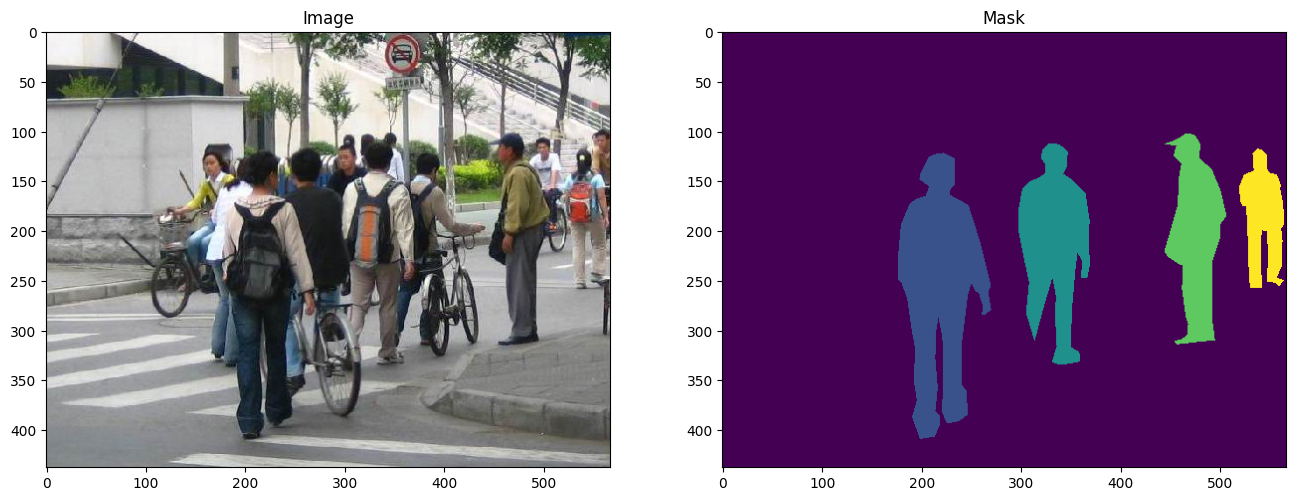

In [15]:
import matplotlib.pyplot as plt
from torchvision.io import read_image

image = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image("data/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))

In [22]:
import os
import torch

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torchvision.transforms import v2 as T

if not TORCH_AVAILABLE:
    print("Для пайплайна детекции нужен PyTorch.")
else:
    #from torchvision.datasets import PennFudanPed
    from torchvision.transforms import v2 as T

    DATA_ROOT = Path.cwd() / "data" / "PennFudanPed"

    image_tf = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

    class PennFudanDetectionDataset(Dataset):
        def __init__(self, root, transforms=None):
            self.root = root
            self.transforms = transforms
            # load all image files, sorting them to
            # ensure that they are aligned
            self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
            self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

        def __getitem__(self, idx):
            # load images and masks
            img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
            mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
            img = read_image(img_path)
            mask = read_image(mask_path)
            # instances are encoded as different colors
            obj_ids = torch.unique(mask)
            # first id is the background, so remove it
            obj_ids = obj_ids[1:]
            num_objs = len(obj_ids)

            # split the color-encoded mask into a set
            # of binary masks
            masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

            # get bounding box coordinates for each mask
            boxes = masks_to_boxes(masks)

            # there is only one class
            labels = torch.ones((num_objs,), dtype=torch.int64)

            image_id = torch.tensor([idx])
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            # suppose all instances are not crowd
            iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

            # Wrap sample and targets into torchvision tv_tensors:
            img = tv_tensors.Image(img)

            target = {}
            target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
            target["masks"] = tv_tensors.Mask(masks)
            target["labels"] = labels
            target["image_id"] = image_id
            target["area"] = area
            target["iscrowd"] = iscrowd

            if self.transforms is not None:
                img, target = self.transforms(img, target)

            return img, target

        def __len__(self):
            return len(self.imgs)

    det_tf = T.Compose([
        T.ToDtype(torch.float32, scale=True),
        T.ToPureTensor(),
    ])
    det_ds = PennFudanDetectionDataset(DATA_ROOT, transforms=det_tf)
    print("Penn-Fudan samples:", len(det_ds))


Penn-Fudan samples: 170


## 6. Faster R-CNN по этапам
![mask1](images/mask1.png)
### Backbone

CNN извлекает feature map из изображения. Это общее представление, на котором работают последующие блоки.

### Region Proposal Network (RPN)

RPN сканирует feature map и предлагает области, которые, скорее всего, содержат объекты. Это еще не финальные detection, а candidate regions.
![mask2](images/mask2.png)
После того как изображение было обработано для выделения ключевых признаков, в дело вступает Region Proposal Network. Эта часть модели рассматривает изображение и предлагает области, которые, вероятно, содержат объекты.

Это достигается путем генерации нескольких возможных местоположений объектов, называемых якорями. Затем сеть оценивает эти якоря и выбирает наиболее перспективные для дальнейшего анализа. Таким образом, модель фокусируется только на областях, которые с наибольшей вероятностью представляют интерес, а не проверяет каждое место на изображении.

### ROI stage

Предложенные области преобразуются в фиксированный размер признакового представления. Так следующий head может обрабатывать их единообразно.
![mask2](images/mask3.png)
После определения ключевых областей следующим шагом является уточнение деталей, извлеченных из этих регионов. Более ранние модели использовали метод, называемый ROI Pooling (объединение областей интереса), для захвата признаков из каждой области, но этот метод иногда приводил к небольшим смещениям при изменении размера областей, что делало его менее эффективным, особенно для небольших или перекрывающихся объектов.

Mask R-CNN улучшает это за счет использования техники, называемой ROI Align (выравнивание области интереса). Вместо округления координат, как это делает ROI Pooling, ROI Align использует билинейную интерполяцию для более точной оценки значений пикселей. Билинейная интерполяция — это метод, который вычисляет новое значение пикселя путем усреднения значений четырех ближайших соседей, что создает более плавные переходы. Это обеспечивает правильное выравнивание признаков с исходным изображением, что приводит к более точному обнаружению и сегментации объектов.

Например, в футбольном матче двух игроков, стоящих близко друг к другу, можно ошибочно принять за одного, потому что их ограничивающие рамки перекрываются. ROI Align помогает разделить их, сохраняя их формы отчетливыми. 

### Detection head

Для каждого proposal head предсказывает:

- class scores  
- уточненные координаты бокса
После того как ROI Align обработает изображение, следующим шагом будет classify объектов и точная настройка их местоположения. Модель рассматривает каждую выделенную область и решает, какой объект в ней находится. Она присваивает различным категориям оценку вероятности и выбирает наилучшее соответствие.

В то же время он корректирует ограничивающие рамки, чтобы лучше соответствовать объектам. Первоначальные рамки могут быть расположены не идеально, поэтому это помогает повысить точность, гарантируя, что каждая рамка плотно окружает обнаруженный объект.

Наконец, Mask R-CNN делает дополнительный шаг: он генерирует подробную маску сегментации для каждого объекта параллельно.
Именно логика «сначала proposal, потом классификация и refinement» делает Faster R-CNN two-stage детектором.


## 7. Anchors и proposals

Anchor — это заранее заданная форма candidate box, привязанная к определенной позиции на feature map.

Зачем это нужно?

Потому что детектору трудно искать произвольные боксы в непрерывном пространстве с нуля. Anchors дают ему разумные стартовые гипотезы для разных масштабов и соотношений сторон.

Даже если современная модель использует другую стратегию назначения, общая интуиция остается важной:

**детекции нужен систематический способ связать позиции на изображении с возможными прямоугольниками.**


Image shape: (3, 536, 559)
Boxes shape: (2, 4)


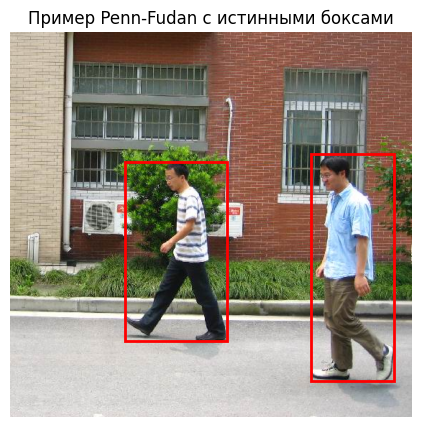

In [23]:
if not TORCH_AVAILABLE:
    print("Пропуск визуализации детекции: PyTorch недоступен.")
else:
    image, target = det_ds[0]
    print("Image shape:", tuple(image.shape))
    print("Boxes shape:", tuple(target["boxes"].shape))

    if MPL_AVAILABLE:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(image.permute(1, 2, 0))
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2,
                    edgecolor="red",
                )
            )
        ax.set_title("Пример Penn-Fudan с истинными боксами")
        ax.axis("off")
        plt.show()


In [24]:
if not TORCH_AVAILABLE:
    print("Пропуск создания детектора: PyTorch недоступен.")
else:
    from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights, fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

    detector = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = detector.roi_heads.box_predictor.cls_score.in_features
    detector.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

    total_params = sum(p.numel() for p in detector.parameters())
    print("Detector parameters:", f"{total_params:,}")


Detector parameters: 41,299,161


## 8. Реальный датасет: Penn-Fudan Pedestrian

Для практики используется Penn-Fudan Pedestrian — тот же небольшой реальный датасет, что и в официальном tutorial `torchvision`.

Почему он хорош для обучения:

- реальные уличные сцены  
- простая задача одного класса  
- легко интерпретировать результаты визуально  
- небольшой размер для быстрых экспериментов

Важно заметить отличие от сегментации: target — это уже не плотная маска, а список объектов переменной длины. Из-за этого меняется и dataloader, и `collate_fn`.


Эпоха 1/5, батч 1/8, loss=0.4752 | loss_classifier: 0.1924, loss_box_reg: 0.2779, loss_objectness: 0.0004, loss_rpn_box_reg: 0.0045
Эпоха 1/5, батч 3/8, loss=0.3358 | loss_classifier: 0.0948, loss_box_reg: 0.2367, loss_objectness: 0.0002, loss_rpn_box_reg: 0.0041
Эпоха 1/5, батч 5/8, loss=0.1724 | loss_classifier: 0.0373, loss_box_reg: 0.1332, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0019
Эпоха 1/5, батч 7/8, loss=0.1552 | loss_classifier: 0.0586, loss_box_reg: 0.0890, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0076

Эпоха 1 завершена. Средняя потеря: 0.2813



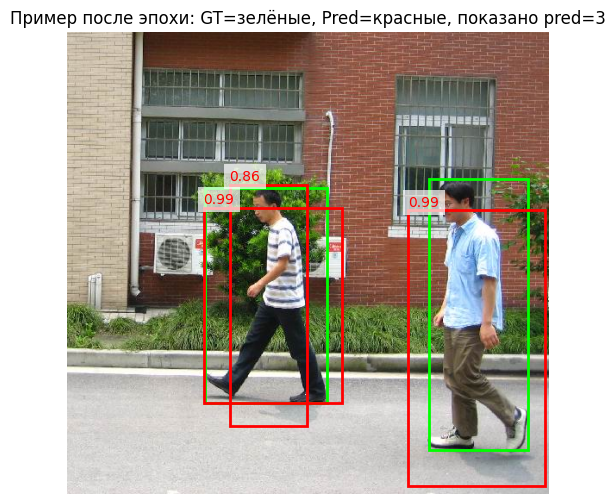

Эпоха 2/5, батч 1/8, loss=0.2688 | loss_classifier: 0.0499, loss_box_reg: 0.2106, loss_objectness: 0.0006, loss_rpn_box_reg: 0.0077
Эпоха 2/5, батч 3/8, loss=0.1289 | loss_classifier: 0.0374, loss_box_reg: 0.0861, loss_objectness: 0.0036, loss_rpn_box_reg: 0.0018
Эпоха 2/5, батч 5/8, loss=0.1150 | loss_classifier: 0.0273, loss_box_reg: 0.0851, loss_objectness: 0.0011, loss_rpn_box_reg: 0.0015
Эпоха 2/5, батч 7/8, loss=0.1294 | loss_classifier: 0.0398, loss_box_reg: 0.0868, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0028

Эпоха 2 завершена. Средняя потеря: 0.1822



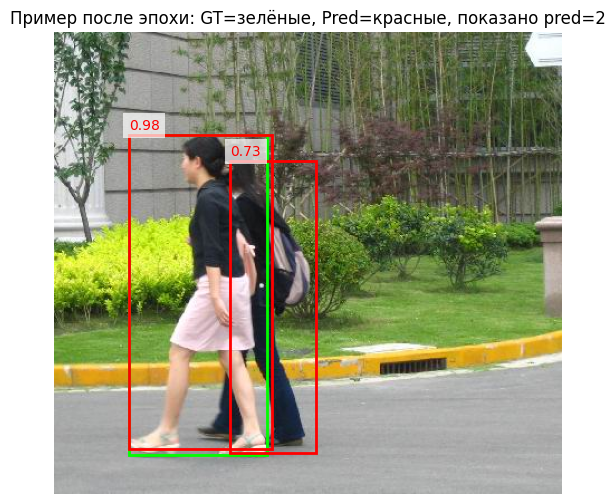

Эпоха 3/5, батч 1/8, loss=0.1383 | loss_classifier: 0.0304, loss_box_reg: 0.1028, loss_objectness: 0.0001, loss_rpn_box_reg: 0.0049
Эпоха 3/5, батч 3/8, loss=0.1368 | loss_classifier: 0.0416, loss_box_reg: 0.0857, loss_objectness: 0.0059, loss_rpn_box_reg: 0.0035
Эпоха 3/5, батч 5/8, loss=0.1028 | loss_classifier: 0.0309, loss_box_reg: 0.0682, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0037
Эпоха 3/5, батч 7/8, loss=0.1571 | loss_classifier: 0.0343, loss_box_reg: 0.1167, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0061

Эпоха 3 завершена. Средняя потеря: 0.1262



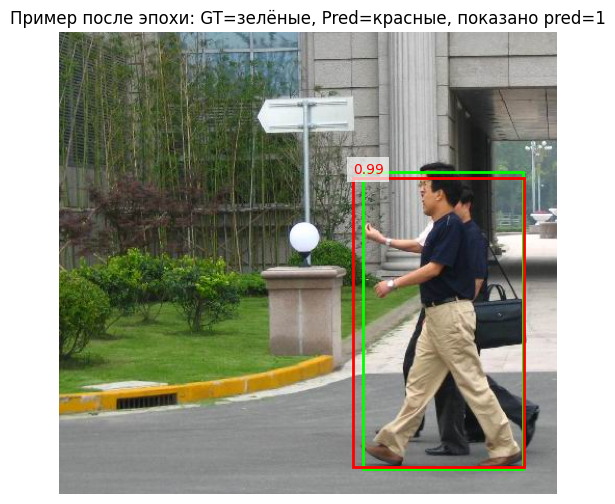

Эпоха 4/5, батч 1/8, loss=0.1218 | loss_classifier: 0.0273, loss_box_reg: 0.0900, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0045
Эпоха 4/5, батч 3/8, loss=0.0774 | loss_classifier: 0.0165, loss_box_reg: 0.0557, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0052
Эпоха 4/5, батч 5/8, loss=0.0868 | loss_classifier: 0.0223, loss_box_reg: 0.0627, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0017
Эпоха 4/5, батч 7/8, loss=0.0690 | loss_classifier: 0.0226, loss_box_reg: 0.0449, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0015

Эпоха 4 завершена. Средняя потеря: 0.0965



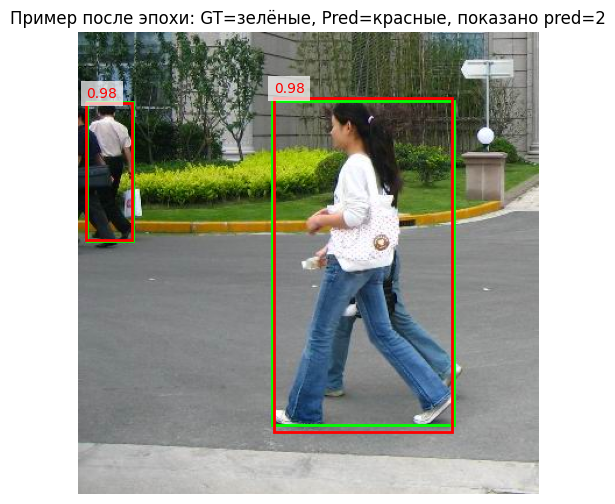

Эпоха 5/5, батч 1/8, loss=0.0699 | loss_classifier: 0.0177, loss_box_reg: 0.0441, loss_objectness: 0.0060, loss_rpn_box_reg: 0.0021
Эпоха 5/5, батч 3/8, loss=0.1008 | loss_classifier: 0.0273, loss_box_reg: 0.0707, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0028
Эпоха 5/5, батч 5/8, loss=0.0467 | loss_classifier: 0.0122, loss_box_reg: 0.0325, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0020
Эпоха 5/5, батч 7/8, loss=0.0701 | loss_classifier: 0.0255, loss_box_reg: 0.0434, loss_objectness: 0.0000, loss_rpn_box_reg: 0.0011

Эпоха 5 завершена. Средняя потеря: 0.0765



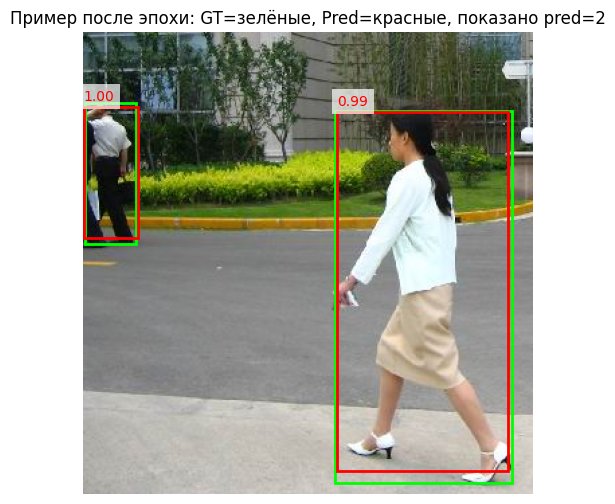

In [27]:
if not TORCH_AVAILABLE:
    print("Пропуск шага обучения: PyTorch недоступен.")
else:
    import random
    import numpy as np

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    detector = detector.to(DEVICE)

    def collate_fn(batch):
        images, targets = zip(*batch)
        return list(images), list(targets)

    # Небольшой subset для demo
    train_indices = list(range(min(16, len(det_ds))))
    train_subset = torch.utils.data.Subset(det_ds, train_indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=2,
        shuffle=True,
        collate_fn=collate_fn,
    )

    optimizer = torch.optim.Adam(
        [p for p in detector.parameters() if p.requires_grad],
        lr=1e-4
    )

    NUM_EPOCHS = 5

    # Для воспроизводимости
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    def move_targets_to_device(targets, device):
        return [
            {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()}
            for t in targets
        ]

    def show_prediction_example(model, dataset, device, sample_idx=0, score_thr=0.5):
        if not MPL_AVAILABLE:
            print("MPL недоступен, визуализация пропущена.")
            return

        model.eval()
        with torch.no_grad():
            image, target = dataset[sample_idx]

            # image для модели
            image_for_model = image.to(device)

            prediction = model([image_for_model])[0]

            # image для matplotlib
            img_vis = image.detach().cpu()
            if img_vis.dtype != torch.float32:
                img_vis = img_vis.float() / 255.0

            fig, ax = plt.subplots(figsize=(7, 6))
            ax.imshow(img_vis.permute(1, 2, 0))

            # Истинные боксы — зелёные
            gt_boxes = target["boxes"].detach().cpu()
            for box in gt_boxes:
                x1, y1, x2, y2 = box.tolist()
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, linewidth=2, edgecolor="lime"
                )
                ax.add_patch(rect)

            # Предсказанные боксы — красные
            pred_boxes = prediction["boxes"].detach().cpu()
            pred_scores = prediction["scores"].detach().cpu()

            shown = 0
            for box, score in zip(pred_boxes, pred_scores):
                if score.item() < score_thr:
                    continue
                x1, y1, x2, y2 = box.tolist()
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, linewidth=2, edgecolor="red"
                )
                ax.add_patch(rect)
                ax.text(
                    x1, max(0, y1 - 5),
                    f"{score.item():.2f}",
                    color="red",
                    fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )
                shown += 1

            ax.set_title(
                f"Пример после эпохи: GT=зелёные, Pred=красные, показано pred={shown}"
            )
            ax.axis("off")
            plt.show()

        model.train()

    for epoch in range(NUM_EPOCHS):
        detector.train()
        epoch_loss = 0.0
        num_batches = 0

        for batch_idx, (images, targets) in enumerate(train_loader):
            images = [img.to(DEVICE) for img in images]
            targets = move_targets_to_device(targets, DEVICE)

            loss_dict = detector(images, targets)
            total_loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss.item()
            num_batches += 1

            if batch_idx % 2 == 0:
                loss_str = ", ".join([f"{k}: {v.item():.4f}" for k, v in loss_dict.items()])
                print(
                    f"Эпоха {epoch+1}/{NUM_EPOCHS}, "
                    f"батч {batch_idx+1}/{len(train_loader)}, "
                    f"loss={total_loss.item():.4f} | {loss_str}"
                )

        avg_loss = epoch_loss / max(1, num_batches)
        print(f"\nЭпоха {epoch+1} завершена. Средняя потеря: {avg_loss:.4f}\n")

        # Показать пример предсказания после эпохи
        show_prediction_example(
            detector,
            train_subset,
            DEVICE,
            sample_idx=epoch % len(train_subset),
            score_thr=0.5
        )

## 9. Почему в коде используется `fasterrcnn_resnet50_fpn`

Этот выбор одновременно практический и учебный.

Практический, потому что:

- есть pretrained weights  
- модель входит в `torchvision`  
- для fine-tuning достаточно заменить небольшую голову

Учебный, потому что:

- архитектура широко известна в литературе  
- она ясно показывает стандартный detection workflow  
- студент легко видит, где именно находятся классификатор и box regressor


## 10. AP и mAP простыми словами

Average Precision суммирует поведение precision-recall кривой для одного класса. Mean Average Precision усредняет AP по классам.

Почему это лучше, чем один фиксированный threshold?

Потому что детектор — это не только локализатор, но и система ранжирования. Если модель ставит хорошие detections выше плохих, это должно отражаться в метрике, даже до выбора конкретного порога.

Именно поэтому серьезную детекцию почти никогда не оценивают одной “accuracy”-подобной метрикой.


## 11. Где детекция используется на практике

Детекция полезна везде, где достаточно примерной локализации:

- аналитика трафика  
- мониторинг полок в ритейле  
- системы безопасности работников  
- спортивная аналитика  
- робототехника и складские системы  
- мониторинг животных и дроны

Во многих production-системах детекция — это front-end этап. Дальше boxes подаются в tracker, counter, OCR или другой downstream-модуль.


Predicted boxes kept after score threshold: 0


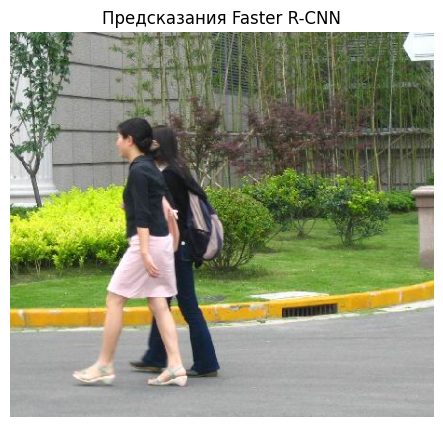

In [26]:
if not TORCH_AVAILABLE:
    print("Пропуск инференса: PyTorch недоступен.")
else:
    detector.eval()
    demo_image, demo_target = det_ds[1]

    with torch.no_grad():
        predictions = detector([demo_image.to(DEVICE)])[0]

    keep = predictions["scores"].cpu() > 0.5
    pred_boxes = predictions["boxes"].cpu()[keep]
    pred_scores = predictions["scores"].cpu()[keep]

    print("Predicted boxes kept after score threshold:", len(pred_boxes))

    if MPL_AVAILABLE:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(demo_image.permute(1, 2, 0))
        for box, score in zip(pred_boxes, pred_scores):
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2,
                    edgecolor="lime",
                )
            )
            ax.text(x1, y1 - 4, f"{score:.2f}", color="lime", fontsize=10, backgroundcolor="black")
        ax.set_title("Предсказания Faster R-CNN")
        ax.axis("off")
        plt.show()


## 12. Типичные ошибки и режимы отказа

Ошибки новичка:

- неправильный формат боксов  
- отсутствие собственного `collate_fn`  
- оценка только «на глаз»  
- неверная интерпретация threshold как качества модели

Частые ошибки самой модели:

- дублирующиеся боксы  
- пропуск маленьких объектов  
- плохая локализация при перекрытиях  
- смещение боксов на фон

При отладке детектора важно смотреть и на:

- сырые предсказания  
- отфильтрованные предсказания после threshold и NMS


In [ ]:
# Заготовка упражнения: сравните score thresholds

if not TORCH_AVAILABLE:
    print("Для упражнения по детекции нужен PyTorch.")
else:
    for thr in [0.3, 0.5, 0.7]:
        keep = predictions["scores"].cpu() > thr
        print(f"threshold={thr:.1f} -> kept boxes={int(keep.sum())}")


## Упражнения

1. Понизьте score threshold и посмотрите на компромисс между precision и количеством «мусора».  
2. Замените Faster R-CNN на RetinaNet или SSD и сравните поведение.  
3. Переведите несколько боксов вручную между `xyxy`, `xywh` и `cxcywh`.  
4. Сделайте не один, а несколько optimization steps и посмотрите, как меняются предсказания.


## Источники

- Материал расширен на основе материалов курса и [deepmachinelearning.ru](https://deepmachinelearning.ru/docs/Neural-networks/Object-detection).  
- Официальный tutorial `torchvision` по object detection finetuning.  
- Статья Faster R-CNN: *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks*.
